# Task 3.3 — Bridging the Modality Gap via Orthogonal Procrustes Alignment

In this notebook, we:
1. **Pair** STL-10 image embeddings with their corresponding text class embeddings.
2. **Solve the Orthogonal Procrustes problem**: $\min_R \|X R - Y\|_F$ subject to $R^T R = I$, using `scipy.linalg.orthogonal_procrustes`.
3. **Apply** the optimal rotation matrix $R$ to align CLIP image embeddings onto the text embedding space.
4. **Visualise** the aligned embeddings using t-SNE and compare against the unaligned modality gap.
5. **Recompute zero-shot classification accuracy** using the Procrustes-aligned embeddings.
6. **Quantify** the improvement: Frobenius norm reduction, centroid gap reduction, and accuracy change.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision

from task3_clip.src.zeroshot import load_clip_model, evaluate_zeroshot, evaluate_zeroshot_aligned, load_stl10_dataset
from task3_clip.src.embeddings import extract_clip_embeddings
from task3_clip.src.procrustes import align_embeddings_procrustes
from task3_clip.src.modality_gap import (
    plot_modality_gap,
    plot_modality_gap_by_class,
    compute_modality_gap_metrics
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

model, preprocess, tokenizer = load_clip_model(device=device)
print('CLIP ViT-B/32 loaded')

Using device: cuda


c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ViT-B/32 loaded


In [2]:
# Load STL-10 with CLIP preprocessing (loads instantly from cached data)
dataset = load_stl10_dataset(root='../data', split='test', transform=preprocess)
class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

# Extract embeddings for Procrustes training (100 samples)
data = extract_clip_embeddings(
    model, tokenizer, preprocess, dataset, class_names,
    num_samples=100, device=device
)

print(f'Extracted {len(data["labels"])} image-text pairs for Procrustes alignment')
print(f'Embedding dimension: {data["norm_img"].shape[1]}')

Extracted 100 image-text pairs for Procrustes alignment
Embedding dimension: 512


### Before Alignment — Visualise the Modality Gap
Baseline t-SNE showing the separated image and text embedding clusters.

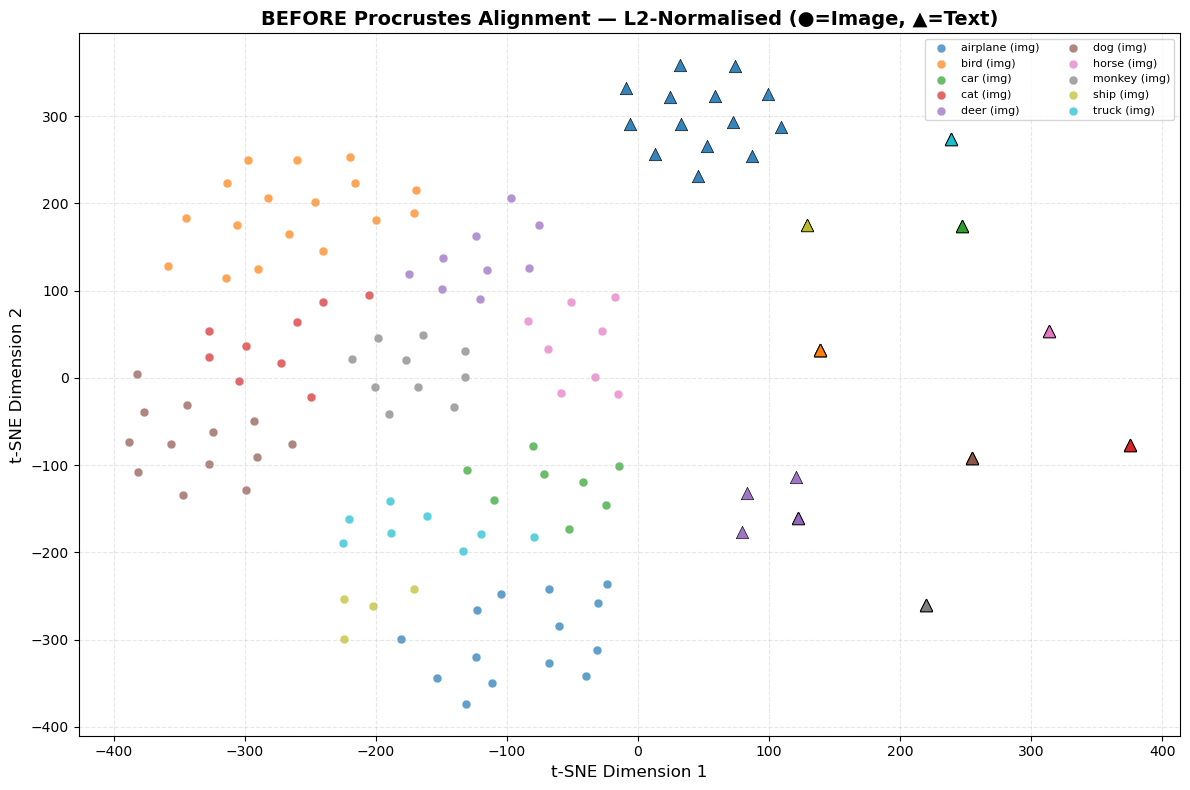

In [3]:
os.makedirs('../results/figures', exist_ok=True)

plot_modality_gap_by_class(
    data['norm_img'], data['norm_txt'], data['labels'], class_names,
    title='BEFORE Procrustes Alignment — L2-Normalised (●=Image, ▲=Text)',
    save_path='../results/figures/before_procrustes_class.png'
)

### Solve the Orthogonal Procrustes Problem
We learn $R$ on the **L2-normalised** embeddings: $\min_R \|X_{\text{img}} R - Y_{\text{txt}}\|_F$ s.t. $R^T R = I$.

In [4]:
# Solve Procrustes: rotate normalised image embeddings to align with text
aligned_img, R, frob_before, frob_after = align_embeddings_procrustes(
    data['norm_img'], data['norm_txt']
)

print(f'Rotation matrix R shape: {R.shape}')
print(f'R is orthogonal: R^T R ≈ I check: {np.allclose(R.T @ R, np.eye(R.shape[0]), atol=1e-5)}')
print(f'\nFrobenius norm ||XR - Y||_F:')
print(f'  Before alignment: {frob_before:.4f}')
print(f'  After alignment:  {frob_after:.4f}')
print(f'  Reduction:        {(1 - frob_after/frob_before)*100:.1f}%')

Rotation matrix R shape: (512, 512)
R is orthogonal: R^T R ≈ I check: True

Frobenius norm ||XR - Y||_F:
  Before alignment: 12.1734
  After alignment:  4.9117
  Reduction:        59.7%


### After Alignment — Visualise Aligned Embeddings
t-SNE of the Procrustes-rotated image embeddings and the original text embeddings.

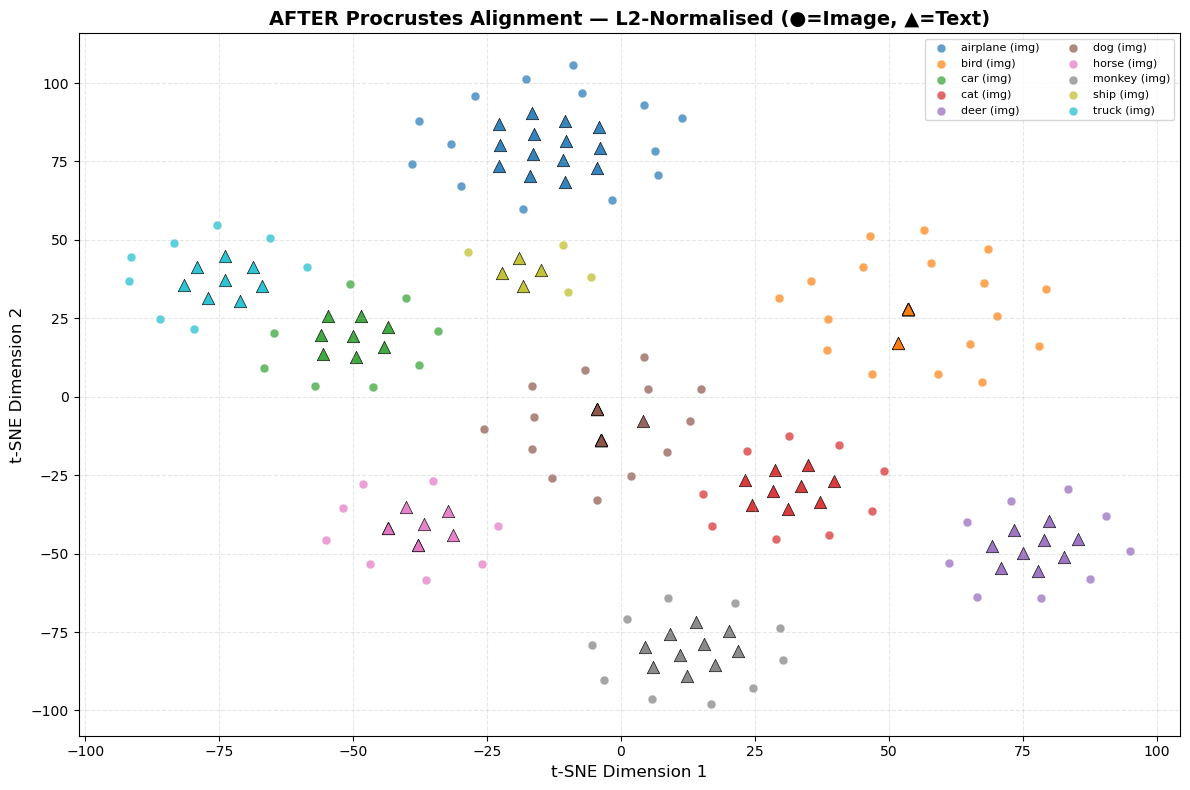

In [5]:
# Re-normalise aligned embeddings for consistent comparison
aligned_img_norm = aligned_img / np.linalg.norm(aligned_img, axis=-1, keepdims=True)

plot_modality_gap_by_class(
    aligned_img_norm, data['norm_txt'], data['labels'], class_names,
    title='AFTER Procrustes Alignment — L2-Normalised (●=Image, ▲=Text)',
    save_path='../results/figures/after_procrustes_class.png'
)

### Side-by-Side: Before vs. After Alignment (Modality-Coloured)

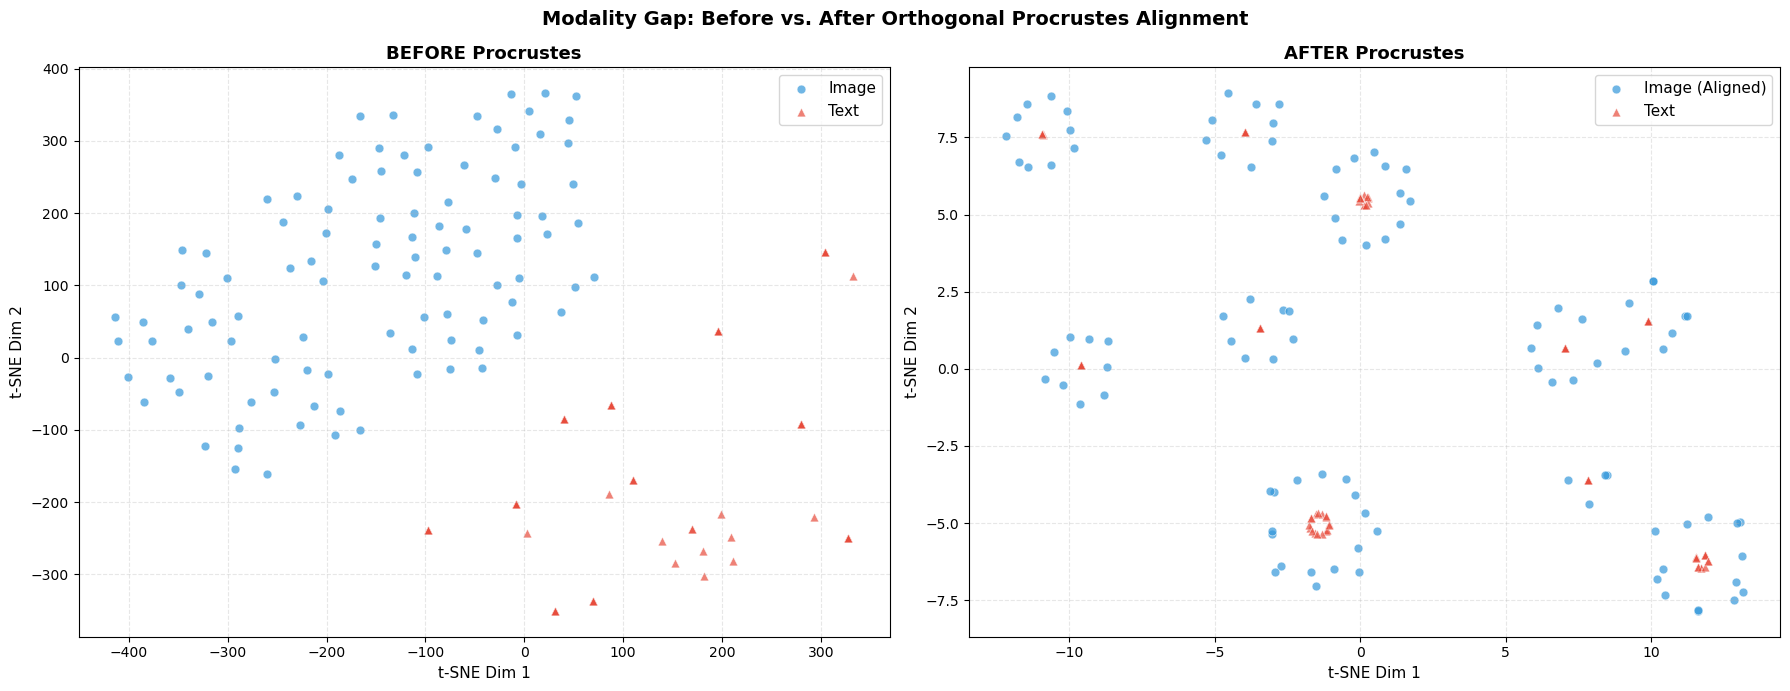

In [6]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Before alignment
combined_before = np.vstack([data['norm_img'], data['norm_txt']])
tsne_before = TSNE(n_components=2, random_state=42, perplexity=25).fit_transform(combined_before)
n = len(data['norm_img'])

axes[0].scatter(tsne_before[:n, 0], tsne_before[:n, 1], c='#3498db', alpha=0.7,
                s=40, label='Image', edgecolors='white', linewidth=0.5)
axes[0].scatter(tsne_before[n:, 0], tsne_before[n:, 1], c='#e74c3c', alpha=0.7,
                s=40, marker='^', label='Text', edgecolors='white', linewidth=0.5)
axes[0].set_title('BEFORE Procrustes', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].set_xlabel('t-SNE Dim 1', fontsize=11)
axes[0].set_ylabel('t-SNE Dim 2', fontsize=11)

# After alignment
combined_after = np.vstack([aligned_img_norm, data['norm_txt']])
tsne_after = TSNE(n_components=2, random_state=42, perplexity=25).fit_transform(combined_after)

axes[1].scatter(tsne_after[:n, 0], tsne_after[:n, 1], c='#3498db', alpha=0.7,
                s=40, label='Image (Aligned)', edgecolors='white', linewidth=0.5)
axes[1].scatter(tsne_after[n:, 0], tsne_after[n:, 1], c='#e74c3c', alpha=0.7,
                s=40, marker='^', label='Text', edgecolors='white', linewidth=0.5)
axes[1].set_title('AFTER Procrustes', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].set_xlabel('t-SNE Dim 1', fontsize=11)
axes[1].set_ylabel('t-SNE Dim 2', fontsize=11)

fig.suptitle('Modality Gap: Before vs. After Orthogonal Procrustes Alignment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/procrustes_before_after_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Quantitative Gap Metrics: Before vs. After

Metric                                 Before          After
Centroid Gap                           1.0612         0.1330
Mean Cosine Sim                        0.2590         0.8794
Intra Img Dist                         0.8431         0.8431
Intra Txt Dist                         0.4803         0.4803


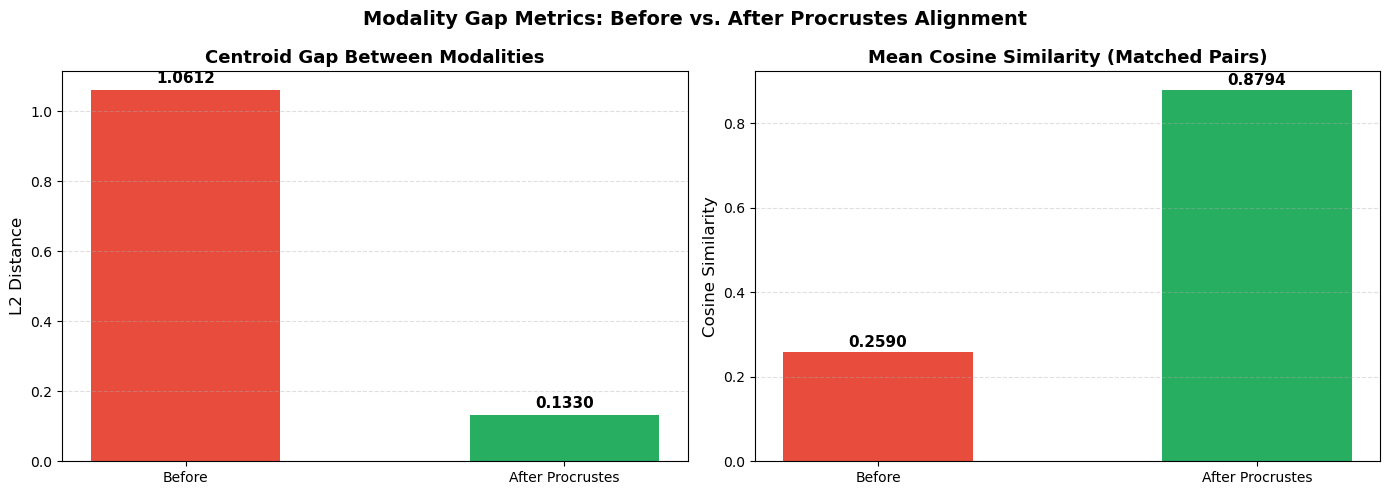

In [7]:
metrics_before = compute_modality_gap_metrics(data['norm_img'], data['norm_txt'])
metrics_after = compute_modality_gap_metrics(aligned_img_norm, data['norm_txt'])

print('=' * 65)
print(f'{"Metric":<30s} {"Before":>14s} {"After":>14s}')
print('=' * 65)
for key in ['centroid_gap', 'mean_cosine_sim', 'intra_img_dist', 'intra_txt_dist']:
    label = key.replace('_', ' ').title()
    print(f'{label:<30s} {metrics_before[key]:>14.4f} {metrics_after[key]:>14.4f}')
print('=' * 65)

# Visualise metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Centroid gap
vals = [metrics_before['centroid_gap'], metrics_after['centroid_gap']]
bars = axes[0].bar(['Before', 'After Procrustes'], vals,
                   color=['#e74c3c', '#27ae60'], width=0.5)
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('L2 Distance', fontsize=12)
axes[0].set_title('Centroid Gap Between Modalities', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Mean cosine similarity
vals2 = [metrics_before['mean_cosine_sim'], metrics_after['mean_cosine_sim']]
bars2 = axes[1].bar(['Before', 'After Procrustes'], vals2,
                    color=['#e74c3c', '#27ae60'], width=0.5)
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Cosine Similarity', fontsize=12)
axes[1].set_title('Mean Cosine Similarity (Matched Pairs)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Modality Gap Metrics: Before vs. After Procrustes Alignment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/procrustes_gap_metrics.png', bbox_inches='tight', dpi=300)
plt.show()

### Recompute Classification Accuracy with Aligned Embeddings
We apply the learned rotation $R$ to **all** image features during inference and compare with the original CLIP accuracy.

In [8]:
# Original CLIP accuracy (template prompt)
acc_original = evaluate_zeroshot(
    model, preprocess, tokenizer, dataset, class_names,
    prompt_strategy='template', device=device
)
print(f'Original CLIP Accuracy (template):  {acc_original*100:.2f}%')

# Procrustes-aligned accuracy
acc_aligned = evaluate_zeroshot_aligned(
    model, preprocess, tokenizer, dataset, class_names,
    R=R, prompt_strategy='template', device=device
)
print(f'Procrustes-Aligned Accuracy:        {acc_aligned*100:.2f}%')

delta = (acc_aligned - acc_original) * 100
print(f'Accuracy Change:                    {"+" if delta >= 0 else ""}{delta:.2f}%')

Original CLIP Accuracy (template):  95.73%
Procrustes-Aligned Accuracy:        96.96%
Accuracy Change:                    +1.24%


In [9]:
# Also evaluate with plain and descriptive prompts for comprehensive comparison
strategies = ['plain', 'template', 'descriptive']
original_accs = []
aligned_accs = []

for s in strategies:
    orig = evaluate_zeroshot(model, preprocess, tokenizer, dataset, class_names,
                            prompt_strategy=s, device=device)
    algn = evaluate_zeroshot_aligned(model, preprocess, tokenizer, dataset, class_names,
                                    R=R, prompt_strategy=s, device=device)
    original_accs.append(orig * 100)
    aligned_accs.append(algn * 100)
    print(f'{s:15s}: Original={orig*100:.2f}%  Aligned={algn*100:.2f}%  Delta={"+" if algn > orig else ""}{(algn-orig)*100:.2f}%')

plain          : Original=96.41%  Aligned=97.09%  Delta=+0.68%
template       : Original=95.73%  Aligned=96.96%  Delta=+1.24%
descriptive    : Original=94.16%  Aligned=96.12%  Delta=+1.96%


### Accuracy Comparison: Original vs. Procrustes-Aligned

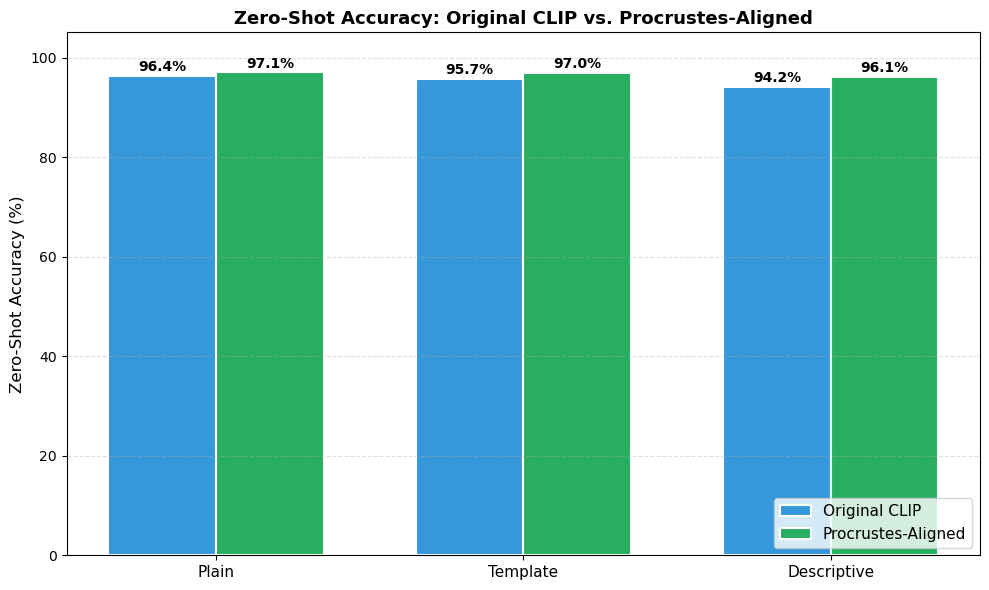

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x - width/2, original_accs, width, label='Original CLIP', color='#3498db',
               edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, aligned_accs, width, label='Procrustes-Aligned', color='#27ae60',
               edgecolor='white', linewidth=1.5)

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Zero-Shot Accuracy (%)', fontsize=12)
ax.set_title('Zero-Shot Accuracy: Original CLIP vs. Procrustes-Aligned',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in strategies], fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, max(max(original_accs), max(aligned_accs)) + 8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../results/figures/procrustes_accuracy_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Frobenius Norm Reduction

<>:10: SyntaxWarning: invalid escape sequence '\|'
<>:10: SyntaxWarning: invalid escape sequence '\|'
C:\Users\moize\AppData\Local\Temp\ipykernel_49224\2958975622.py:10: SyntaxWarning: invalid escape sequence '\|'
  ax.set_ylabel('Frobenius Norm $\|XR - Y\|_F$', fontsize=12)


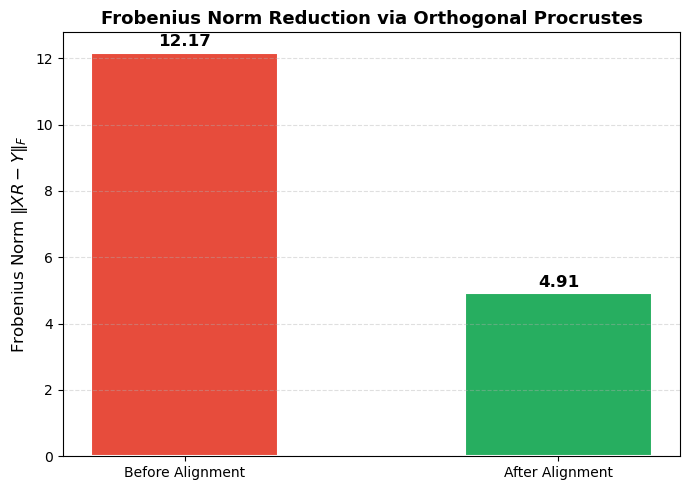

Frobenius norm reduction: 12.17 → 4.91 (59.7% reduction)


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(['Before Alignment', 'After Alignment'],
              [frob_before, frob_after],
              color=['#e74c3c', '#27ae60'], width=0.5, edgecolor='white', linewidth=1.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Frobenius Norm $\|XR - Y\|_F$', fontsize=12)
ax.set_title('Frobenius Norm Reduction via Orthogonal Procrustes',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../results/figures/frobenius_norm_reduction.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'Frobenius norm reduction: {frob_before:.2f} → {frob_after:.2f} ({(1 - frob_after/frob_before)*100:.1f}% reduction)')